# DNN — PyTorch (GPU-Accelerated)

## Model: Deep Neural Network (Multi-Layer Perceptron)
- **Dataset**: UCI HAR — 7,352 train / 2,947 test, 561 sensor features
- **Task**: Classify 6 human activities (3 dynamic, 3 static)
- **Framework showcase**: BatchNorm + Dropout + LR scheduling — full regularization toolkit

## GPU Acceleration Strategy
- All tensor ops on CUDA (forward pass, backprop, loss computation)
- `nn.Module` subclass with configurable hidden layers
- Adam optimizer with `ReduceLROnPlateau` scheduler
- float32 on GPU, manual train/val split for early stopping

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.visualization import (plot_confusion_matrix_multiclass,
                                  plot_per_class_f1, plot_training_history)
from utils.metrics import evaluate_classifier
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Configuration
RANDOM_STATE = 113
FRAMEWORK = "PyTorch"
N_CLASSES = 6
BATCH_SIZE = 64
ACTIVITY_NAMES = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING"
]

# Reproducibility
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load preprocessed UCI HAR
X_train_np, X_test_np, y_train_np, y_test_np, meta = load_processed_data('dnn')

# Convert to GPU tensors
X_train = torch.tensor(X_train_np, dtype=torch.float32, device=device)
y_train = torch.tensor(y_train_np, dtype=torch.long, device=device)
X_test = torch.tensor(X_test_np, dtype=torch.float32, device=device)
y_test = torch.tensor(y_test_np, dtype=torch.long, device=device)

# Train/val split (90/10 from train, matching SK's validation_fraction)
n_val = int(len(X_train) * 0.1)
indices = torch.randperm(len(X_train), device=device)
val_idx, train_idx = indices[:n_val], indices[n_val:]

X_val = X_train[val_idx]
y_val = y_train[val_idx]
X_train_split = X_train[train_idx]
y_train_split = y_train[train_idx]

# DataLoader for mini-batch training
train_dataset = TensorDataset(X_train_split, y_train_split)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print("=" * 60)
print(f"[1/8] Data loaded — {FRAMEWORK} DNN")
print("=" * 60)
print(f"  Device: {device} ({torch.cuda.get_device_name(0)})")
print(f"  Train: {X_train_split.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"  Classes: {N_CLASSES} ({', '.join(ACTIVITY_NAMES)})")
print(f"  Batch size: {BATCH_SIZE} ({len(train_loader)} batches/epoch)")
print(f"  GPU memory: {torch.cuda.memory_allocated() / 1e6:.1f} MB")

[1/8] Data loaded — PyTorch DNN
  Device: cuda (NVIDIA GeForce RTX 4090)
  Train: torch.Size([6617, 561]) | Val: torch.Size([735, 561]) | Test: torch.Size([2947, 561])
  Classes: 6 (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING)
  Batch size: 64 (104 batches/epoch)
  GPU memory: 40.1 MB


In [2]:
# Step 2: Simple baseline — single hidden layer, same as SK baseline

# nn.Module lets us define arbitrary architectures (SK's MLPClassifier is more rigid)

print("=" * 60)
print("[2/8] SIMPLE BASELINE DNN")
print("=" * 60)

class SimpleDNN(nn.Module):
    """Simple DNN with configurable hidden layers.

    Args:
        input_dim: Number of input features.
        hidden_sizes: Tuple of hidden layer sizes.
        n_classes: Number of output classes.
    """

    def __init__(self, input_dim, hidden_sizes, n_classes):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_model(model, train_loader, X_val, y_val, n_epochs=200, patience=15, lr=0.001):
    """Train with Adam + early stopping on val accuracy.

    Args:
        model: nn.Module to train.
        train_loader: DataLoader for training batches.
        X_val: Validation features tensor.
        y_val: Validation labels tensor.
        n_epochs: Max training epochs.
        patience: Early stopping patience.
        lr: Learning rate.

    Returns:
        dict with train_loss, val_acc lists and best_epoch.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_state = None
    no_improve = 0

    for epoch in range(n_epochs):
        # Training
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(y_batch)

        avg_loss = epoch_loss / len(train_loader.dataset)
        history['train_loss'].append(avg_loss)

        # Validation
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_preds = val_logits.argmax(dim=1)
            val_acc = (val_preds == y_val).float().mean().item()
        history['val_acc'].append(val_acc)

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = epoch + 1
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    # Restore best weights
    model.load_state_dict(best_state)
    history['best_epoch'] = best_epoch
    return history

# Train simple baseline (128,) — same as SK
baseline = SimpleDNN(561, (128,), N_CLASSES).to(device)
history_base = train_model(baseline, train_loader, X_val, y_val, n_epochs=200, patience=15)

# Evaluate on test set
baseline.eval()
with torch.no_grad():
    y_pred_base = baseline(X_test).argmax(dim=1).cpu().numpy()

base_metrics = evaluate_classifier(y_test_np, y_pred_base)

print(f"\n  Architecture: 561 → 128 → 6")
print(f"  Epochs: {len(history_base['train_loss'])} (best at {history_base['best_epoch']})")
print(f"  Final train loss: {history_base['train_loss'][-1]:.4f}")
print(f"  Best val acc: {max(history_base['val_acc']):.4f}")
print(f"\n  Test Results:")
print(f"    Accuracy: {base_metrics['accuracy']:.4f}")
print(f"    Macro F1: {base_metrics['macro_f1']:.4f}")

[2/8] SIMPLE BASELINE DNN

  Architecture: 561 → 128 → 6
  Epochs: 35 (best at 20)
  Final train loss: 0.0007
  Best val acc: 0.9837

  Test Results:
    Accuracy: 0.9393
    Macro F1: 0.9396


[3/8] TRAINING HISTORY


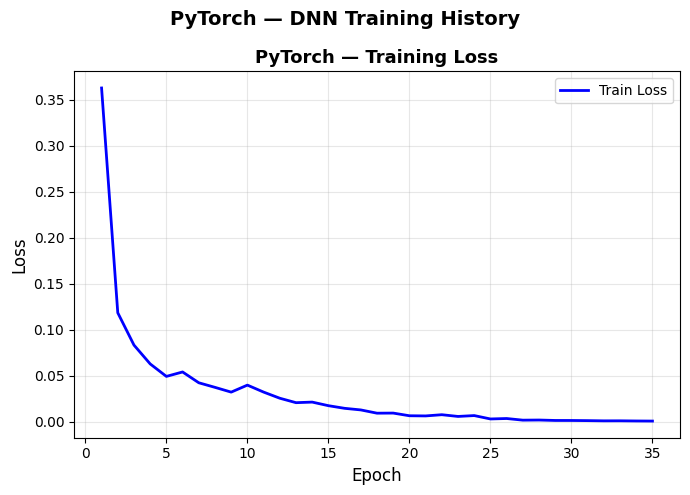

  Epochs: 35
  Loss: 0.3628 → 0.0007
  Val acc: 0.9537 → 0.9837
  Best epoch: 20


In [3]:
# Step 3: Visualize baseline training curves
print("=" * 60)
print("[3/8] TRAINING HISTORY")
print("=" * 60)

plot_training_history(history_base, FRAMEWORK,
                      save_path=f'{RESULTS_DIR}/training_history_baseline.png')

print(f"  Epochs: {len(history_base['train_loss'])}")
print(f"  Loss: {history_base['train_loss'][0]:.4f} → {history_base['train_loss'][-1]:.4f}")
print(f"  Val acc: {history_base['val_acc'][0]:.4f} → {max(history_base['val_acc']):.4f}")
print(f"  Best epoch: {history_base['best_epoch']}")